In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from collections import defaultdict
from pathlib import Path

/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Create strata.

In [2]:
# Remove NA & non-numeric columns and normalize with z-score for PCA.

scaler = preprocessing.StandardScaler()

# Load attributes and hydrologic indices.
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

# Drop Na and non-numeric columns, to prep for clustering.
no_na_attributes = basin_stca_gdf.dropna().sort_index()
numeric_attributes = no_na_attributes.select_dtypes(include=["number"])
scaled_attributes = pd.DataFrame(
    scaler.fit_transform(numeric_attributes.values),
    columns=numeric_attributes.columns,
    index=numeric_attributes.index
)

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
    scaler.fit_transform(numeric_hy_id.values),
    columns=numeric_hy_id.columns,
    index=numeric_hy_id.index
)

# Remove basins for which no hy_id exists. 
common_ids = scaled_attributes.index.intersection(scaled_hy_id.index)
scaled_attributes = scaled_attributes.loc[common_ids]
scaled_hy_id = scaled_hy_id.loc[common_ids]

In [3]:
len(common_ids)

841

In [4]:
# PCA since there are a lot of attributes, which are sometimes correlated. 

pca = PCA(n_components=0.9, svd_solver="full")
pca_attributes = pca.fit_transform(scaled_attributes)

/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


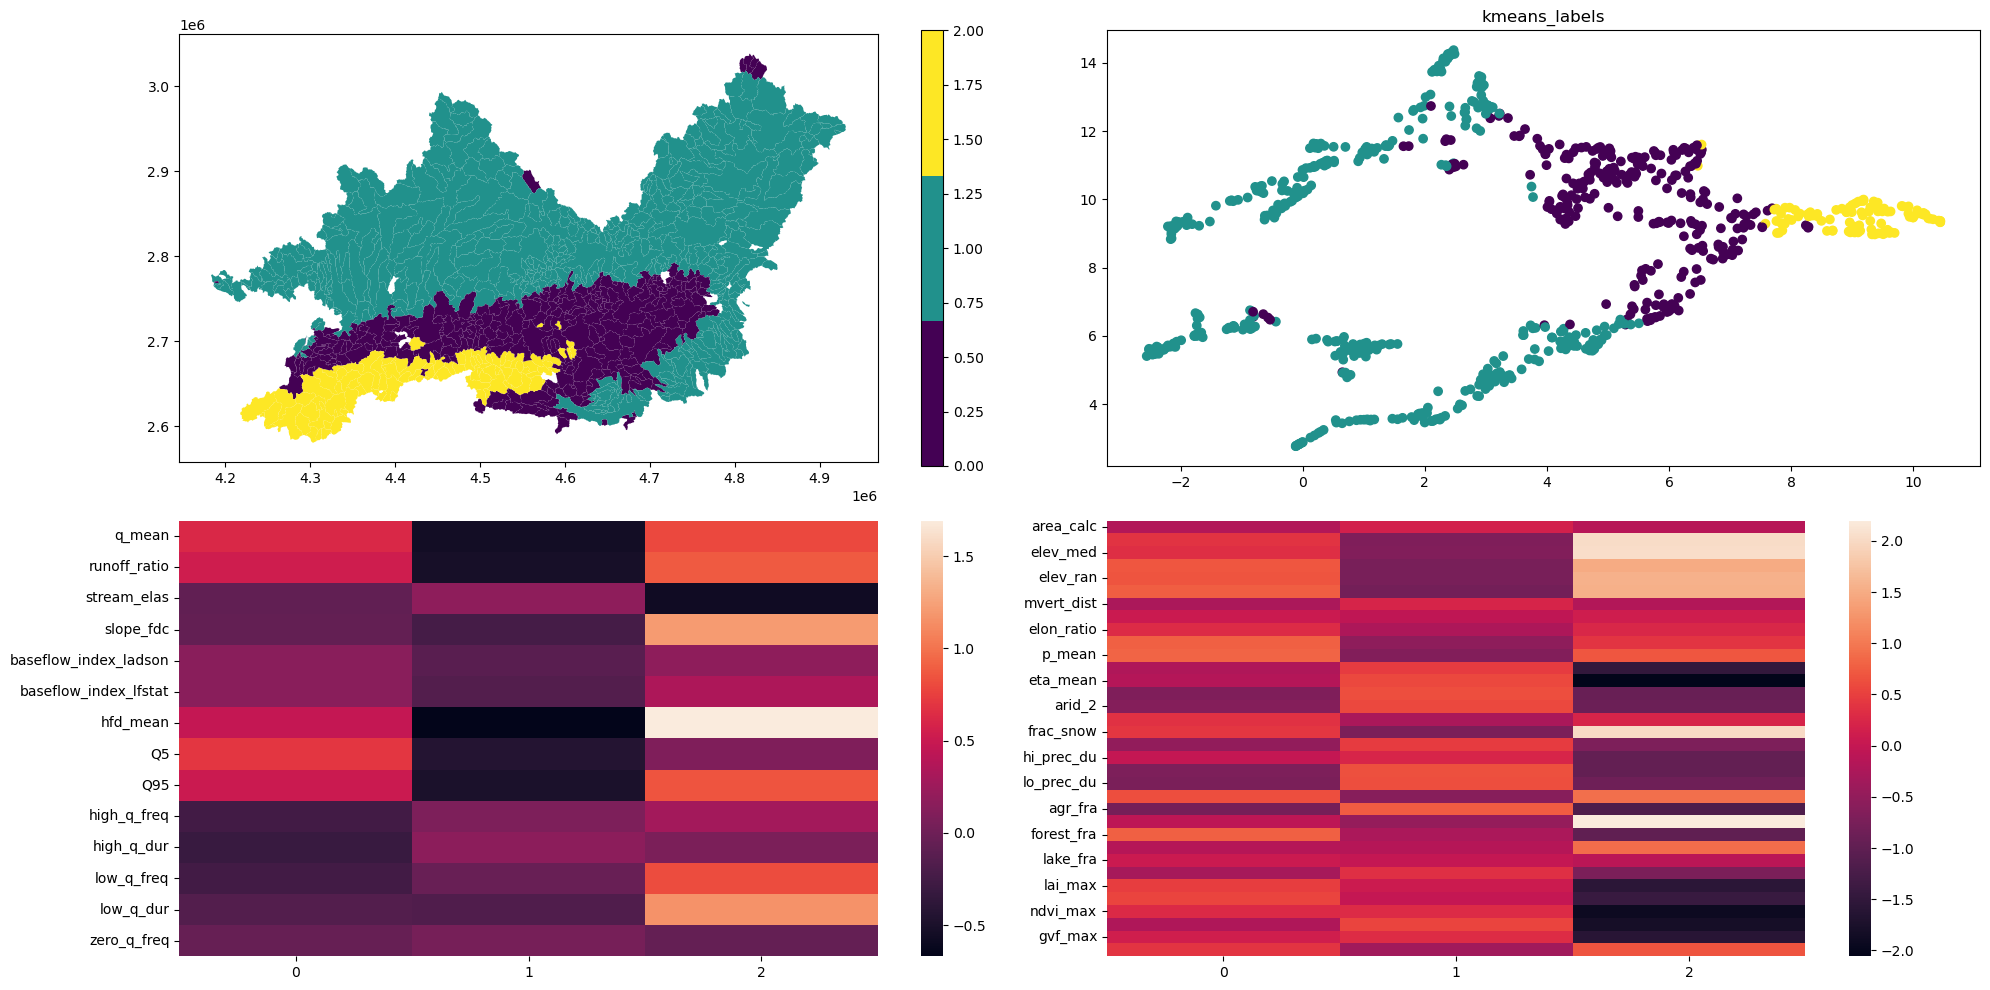

In [5]:
n_clusters = 3
seed =  42 

# KMEANS
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)

# Fit on normal basins. 
kmeans_labels = pd.Series(kmeans.fit_predict(pca_attributes), scaled_attributes.index)

# PLOT
plot_gdf = no_na_attributes.loc[common_ids].copy()
plot_gdf["kmeans_labels"] = kmeans_labels

# Assign one fix color for each cluster
cmap = mpl.colormaps["viridis"].resampled(n_clusters)
vmin = plot_gdf["kmeans_labels"].min()
vmax = plot_gdf["kmeans_labels"].max()

fig, axs = plt.subplots(2,2,figsize=(20,10))

plot_gdf.plot(
    ax=axs[0,0],
    column="kmeans_labels",
    cmap=cmap, vmin=vmin, vmax=vmax,
    legend=True)

reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
)

umap2d = reducer.fit_transform(pca_attributes)
plot_gdf[["UMAP1","UMAP2"]] = umap2d

axs[0,1].scatter(plot_gdf["UMAP1"], plot_gdf["UMAP2"], c=kmeans_labels)

axs[0,1].set_title("kmeans_labels")


# Calculate mean values of hydro id per cluster group.
hy_id_mean_df = scaled_hy_id.groupby(kmeans_labels).mean()

sns.heatmap(ax=axs[1,0],data = scaled_hy_id.groupby(kmeans_labels).mean().transpose())
sns.heatmap(ax=axs[1,1], data = scaled_attributes.iloc[:,:34].groupby(kmeans_labels).mean().transpose())

plt.tight_layout()

#### Assess plausibility of clusters.

Text(0.5, 1.0, 'DB_scores')

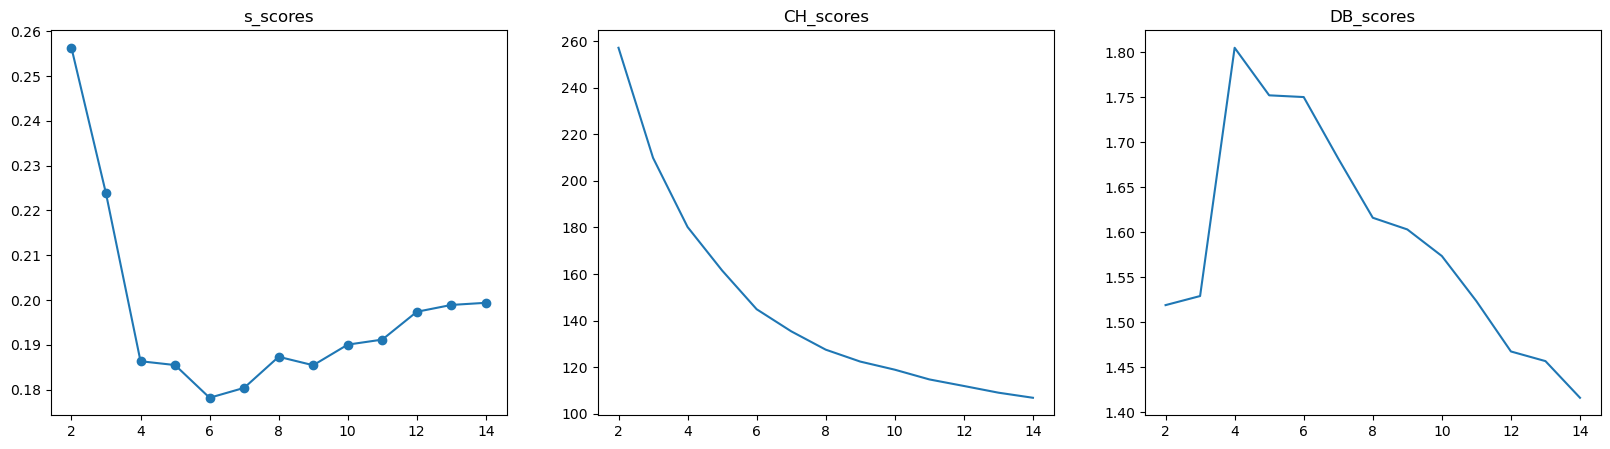

In [6]:
n_seeds = 10

seeds = [12312, 14535, 2345456, 23434, 346667, 7978, 45454, 72673, 6, 2562426] 


s_scores = np.zeros([n_seeds,15]) 
CH_scores =  np.zeros([n_seeds,15])
DB_scores =  np.zeros([n_seeds,15])

for i in range(0,n_seeds):

    seed = seeds[i]

    for k in range(2,15):

        # Test for k-means.
        labels = KMeans(k,random_state=seed).fit_predict(pca_attributes)
        s_scores[i,k] = silhouette_score(pca_attributes,labels) # higher is better
        CH_scores[i,k] = calinski_harabasz_score(pca_attributes,labels) # higher is better
        DB_scores [i,k] = davies_bouldin_score(pca_attributes, labels) # lower is better

avg_s_scores = s_scores.mean(axis=0)[2:]
avg_ch_scores = CH_scores.mean(axis=0)[2:]
avg_db_scores = DB_scores.mean(axis=0)[2:]

fig, axs = plt.subplots(1,3, figsize=(20,5))

axs[0].plot(range(2,15), avg_s_scores, marker="o")
axs[1].plot(range(2,15), avg_ch_scores)
axs[2].plot(range(2,15), avg_db_scores)

axs[0].set_title("s_scores")
axs[1].set_title("CH_scores")
axs[2].set_title("DB_scores")


In [7]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(random_state=42)

rf_train_id, rf_test_id = train_test_split(kmeans_labels.index, train_size=0.8, random_state=42)

RF.fit(scaled_attributes.loc[rf_train_id,:], kmeans_labels[rf_train_id])

rf_pred = RF.predict(scaled_attributes.loc[rf_test_id,:])

results = kmeans_labels[rf_test_id] == rf_pred

print(f"Accuracy of {results.sum()/len(results)}")

feature_importances = pd.Series(RF.feature_importances_, index=scaled_attributes.columns)

Accuracy of 0.9644970414201184


In [8]:
feature_importances.sort_values(ascending=False)

slope_mean    0.118530
frac_snow     0.095656
elev_mean     0.079697
elev_ran      0.079467
elev_med      0.078358
elev_std      0.067597
eta_mean      0.039861
agr_fra       0.037255
arid_2        0.035267
soil_condu    0.033979
clay_fra      0.029871
bedrk_dep     0.029708
bare_fra      0.023499
lo_prec_du    0.023464
lai_max       0.018220
ndvi_min      0.017468
sand_fra      0.016017
lo_prec_fr    0.014696
p_mean        0.014062
forest_fra    0.013315
soil_poros    0.011564
arid_1        0.011373
silt_fra      0.009256
gc_sc_fra     0.008866
geol_poros    0.008586
ndvi_max      0.008117
hi_prec_fr    0.007783
gvf_max       0.006632
et0_mean      0.005857
strm_dens     0.005775
lai_diff      0.005619
lc_dom        0.005204
soil_tawc     0.003875
gvf_diff      0.003655
p_season      0.003534
root_dep      0.003145
grav_fra      0.002769
urban_fra     0.002501
geol_perme    0.002441
NEXTDOWNID    0.002394
oc_fra        0.001678
gc_mt_fra     0.001653
elon_ratio    0.001614
mvert_ang  

Ask Bruno, if there exists a priori knowlegde of how many clusters there should be.

Heatmap suffices, no further statistical needed. 

Strong spatial autocorrelation --> convex cluster. 

regional modelling problem, ask Bruno. 

#### Sample a stratified training and validation set. 

In [9]:
seed = 42 

train_ids = []
val_ids = []
test_ids = []

for strata in kmeans_labels.unique(): 

    # Randomly sample 80% of strata for training.
    strata_train_ids, strata_rest_ids = train_test_split(kmeans_labels[kmeans_labels == strata], train_size=0.8)

    # Split the remaining 20% into validation and test. 
    strata_val_ids, strata_test_ids = train_test_split(strata_rest_ids, train_size=0.5)

    train_ids.extend(strata_train_ids.index.to_list())
    val_ids.extend(strata_val_ids.index.to_list())
    test_ids.extend(strata_test_ids.index.to_list())

train_ids.sort()
val_ids.sort()
test_ids.sort()

In [10]:
len(test_ids)

85

#### Determine static catchment attributes to be used.

/tmp/ipykernel_588547/906420871.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


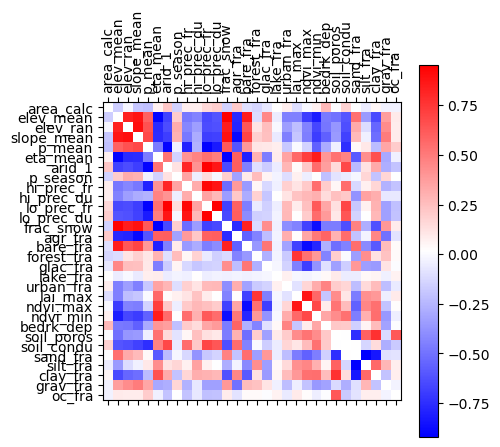

In [11]:
potential_attributes = [
    #geomorph
    "area_calc",
    "elev_mean",
    "elev_ran",
    "slope_mean",

    #precipitation
    "p_mean",
    "eta_mean",
    "arid_1",
    "p_season",
    "hi_prec_fr",
    "hi_prec_du",
    "lo_prec_fr",
    "lo_prec_du",
    "frac_snow",

    #land cover 
    "agr_fra",
    "bare_fra",
    "forest_fra",
    "glac_fra",
    "lake_fra",
    "urban_fra",

    #vegetation
    "lai_max",
    "ndvi_max",
    "ndvi_min",

    #soil
    "bedrk_dep",
    "soil_poros",
    "soil_condu",
    "sand_fra",
    "silt_fra",
    "clay_fra",
    "grav_fra",
    "oc_fra"
]

len(potential_attributes)

filtered_attributes = scaled_attributes[potential_attributes]

corr_mat = filtered_attributes.corr()

for i in range(len(corr_mat)): 

    corr_mat.iloc[i,i] = np.nan

plt.matshow(corr_mat, cmap="bwr")
plt.yticks(ticks=range(len(corr_mat)), labels=corr_mat.columns)
plt.xticks(ticks=range(len(corr_mat)), labels=corr_mat.columns, rotation=90)
plt.colorbar()
plt.tight_layout()

In [12]:
len(scaled_attributes.columns)

60

#### Specify the time periods.

##### Visualize normal periods for a subsample of basins. 

Basin 55 is the odd one out, it shows systematic gaps, and is therefore not usable.

In [13]:
discharge_coverage_path = Path("~/BA/data/processed_data/eda/discharge_coverage.pkl")

discharge_coverage = pd.read_pickle(discharge_coverage_path)

In [14]:
min_normal_len = 1 

In [20]:
#fig, ax = plt.subplots(figsize=(10, len(discharge_coverage) * 0.25))

yticks = []
yticklabels = []

# Test pickling. 
train_dict = defaultdict(dict)
val_dict = defaultdict(dict)
test_dict = defaultdict(dict)


for basin in discharge_coverage.itertuples():

    basin_id = basin[0]

    # Skip basins, which don't have hydrological IDs. 
    if basin_id not in common_ids: 
        continue

    basin_dict = {
        "start_dates": [],
        "end_dates" : []
    }
    normal_periods = []

    for period in basin[-2]: 

        x_min = period[0]
        x_width = (period[1] - period[0])

        if x_width.days > min_normal_len: 
            normal_periods.append((x_min,x_width))

            # Attach for pickling. 
            basin_dict["start_dates"].append(period[0])
            basin_dict["end_dates"].append(period[1])

    #ax.broken_barh(xranges=normal_periods, yrange=(len(yticks), 0.5))


    if basin_id in train_ids: 
        train_dict[str(basin_id)] = basin_dict
    elif basin_id in val_ids:
        val_dict[str(basin_id)] = basin_dict
    else: 
        test_dict[str(basin_id)] = basin_dict

    #yticks.append(len(yticks))
    #yticklabels.append(basin[0])

#ax.set_yticks(yticks)
#ax.set_yticklabels(yticklabels)
#ax.set_ylim(-1,len(yticks)+1)

#plt.tight_layout()
#plt.show()


In [29]:
n_samples = 0

for basin in discharge_coverage.loc[common_ids,"q5_q95_normal_periods"]: 

    for period in basin: 

        duration = (period[1] - period[0]).days

        if duration >= min_normal_len:
            n_samples += duration

print(n_samples)

9338622


#### Export time periods as .pkl and basin id splits as .txt.

In [23]:
import pickle as pkl

splits_directory_path = Path("/home/wuhlmann/BA/data/processed_data/test_splits")

with open(splits_directory_path / "train.pkl", "wb") as out: 
    pkl.dump(train_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "val.pkl", "wb") as out: 
    pkl.dump(val_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "test.pkl", "wb") as out: 
    pkl.dump(test_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

In [24]:
with open(splits_directory_path / "train_basin_ids.txt", "w") as f: 
    for id in train_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "val_basin_ids.txt", "w") as f: 
    for id in val_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "test_basin_ids.txt", "w") as f: 
    for id in test_dict.keys():
        f.write(f"{id}\n")